# Time-frequency representations of power

Oscillatory brain activity is dominated by activity in distinct frequency bands (e.g., theta, alpha, beta, gamma), each of which is differentially modulated depending on the nature and demands of a cognitive or sensory task [1]. To investigate these frequency-specific changes in neural dynamics, time–frequency representations (TFRs) of oscillatory power are computed on a single-trial basis and subsequently averaged across trials. This approach enables the quantification of transient changes in power over time and across frequencies relative to a stimulus or event.

Power estimates are obtained using a Fourier transform in combination with a sliding-window approach, which allows the signal to be decomposed into its constituent frequencies over time while maintaining good temporal resolution. This method captures event-related spectral perturbations (ERSPs), such as stimulus-induced increases or decreases in oscillatory power, which may not be phase-locked to the stimulus and therefore are not evident in traditional averaging techniques such as event-related fields (ERFs) or event-related potentials (ERPs).

The aim of this section is to characterise how oscillatory brain activity is modulated in response to visual input. By analysing the temporal and spectral properties of these responses, we can gain insight into the neural mechanisms underlying sensory processing and attentional engagement.

## Preparation

Import the relevant Python modules:

In [5]:
import os.path as op
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

import mne
from mne_bids import BIDSPath, read_raw_bids

#### File overview

This chapter relies on the epoched data produced in the previous chapter (embedded in the BIDS structure):

`<BIDS_ROOT>/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif`

Set the paths for the data below. Note that these will depend on your local setup.

## Loading the Data

In [6]:
subject = '01'
session = '01'
task    = 'SpAtt'
run     = '01'
meg_suffix = 'meg'
epo_suffix = 'epo'

# Root folder holding the BIDS dataset. Adjust to your local setup.
#data_path = 'C:/Users/rakshita/Documents/Cerca_raw_files'
data_path = '/Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjA'

bids_root  = op.join(data_path, "Cerca_Spatt_BIDS")
deriv_root = op.join(bids_root, "derivatives/analysis")

# Path to the epoched data produced in the previous chapter (input)
bids_path = BIDSPath(subject=subject, session=session,
            task=task, run=run, suffix=epo_suffix, datatype='meg',
            root=deriv_root, extension='.fif', check=False)

print(bids_path.basename, bids_path.fpath)

sub-01_ses-01_task-SpAtt_run-01_epo.fif /Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjA/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif


Read the trial-based data stored as epochs:

In [7]:
epochs = mne.read_epochs(bids_path.fpath,
                         proj = True,
                         preload=True,
                         verbose=True)

Reading /Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjA/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif ...
    Read a total of 8 projection items:
        HFC: l=1 m=0 (1 x 176) active
        HFC: l=2 m=0 (1 x 176) active
        HFC: l=1 m=-1 (1 x 176) active
        HFC: l=1 m=1 (1 x 176) active
        HFC: l=2 m=-1 (1 x 176) active
        HFC: l=2 m=1 (1 x 176) active
        HFC: l=2 m=-2 (1 x 176) active
        HFC: l=2 m=2 (1 x 176) active
    Found the data of interest:
        t =    -749.33 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
229 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 8)
8 projection items activated


Now isolate the OPM sensors that correspond to conventional magnetometers, i.e. the radial (Z-axis) channels, and split the epochs into the left- and right-cue trials:

In [8]:
OPMZ = [item for item in epochs.info['ch_names'] if item.endswith("Z") and not item.startswith("BNC")]

epochsL = epochs['cue_Left'].copy().pick(OPMZ)
epochsR = epochs['cue_Right'].copy().pick(OPMZ)

## Time–frequency analysis of the slower frequencies (< 30 Hz)

From experience we know that oscillations in the slower bands — theta, alpha and beta — are fairly narrow-band (ΔF ~ 2 Hz), whereas gamma-band activity (60–90 Hz) is typically more broad-band (ΔF ~ 5–10 Hz). We therefore use different settings for the slower and faster frequencies.

We use the **multitaper** method, implemented as a sliding time-window approach in which a Fourier transform estimates the spectral power (in MNE-Python via a convolution). Within each window the data are multiplied by one or more orthogonal *tapers* before the Fourier transform [2,3]; the tapers are discrete prolate spheroidal (Slepian) sequences (DPSS).

Three parameters control the analysis:

- `freqs` — the frequencies analysed; here 3 to 30 Hz in 1 Hz steps.
- `n_cycles` — the length of the sliding window in cycles. At *f* Hz one cycle lasts 1/*f* s, so `n_cycles = freqs/2` gives a fixed window of ΔT = 0.5 s at every frequency (e.g. at 10 Hz, `n_cycles` = 5 → ΔT = 500 ms).
- `time_bandwidth` — the time × bandwidth product (ΔT · full bandwidth). It fixes both the number of DPSS tapers, N = `time_bandwidth` − 1, and the spectral smoothing, given by the half-bandwidth W = `time_bandwidth` / (2·ΔT). Here `time_bandwidth = 2.0` with ΔT = 0.5 s gives N = 1 taper and a half-bandwidth of ±2 Hz (4 Hz full width) — narrow, appropriate for the slow rhythms.

To compute the TFR across all sensors for the attend-left and attend-right conditions separately:

In [9]:
freqs = np.arange(3, 31, 1)
n_cycles = freqs / 2 
time_bandwidth = 2.0

tfr_slowL =  epochsL.compute_tfr(
    method = "multitaper",
    freqs=freqs, 
    n_cycles=n_cycles,
    time_bandwidth=time_bandwidth, 
    picks = 'mag',
    use_fft=True, 
    return_itc=False,
    average=True, 
    decim=1,
    n_jobs = -1)

tfr_slowR =  epochsR.compute_tfr(
    method = "multitaper",
    freqs=freqs, 
    n_cycles=n_cycles,
    time_bandwidth=time_bandwidth, 
    picks = 'mag',
    use_fft=True, 
    return_itc=False,
    average=True, 
    decim=1,
    n_jobs = -1)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:   11.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:    4.7s finished



Note that n_jobs = -1 allow for parallel execution which is more efficient if you have a multicore CPU.

Use the plot function to show the 'raw' TFR of from a posterior sensor in the interval -0.5 to 1.7 s aligned to the onset of the cue.


No baseline correction applied


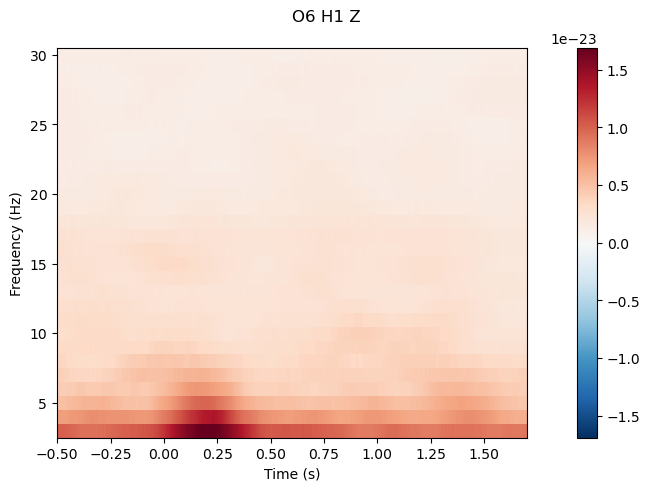

In [10]:
%matplotlib inline
sensor = 'O6 H1 Z'
tfr_slowL.plot(
    picks=sensor,
    tmin=-0.5, tmax=1.7, 
    title=sensor);  

Observe the power increase around ~0.2 s at 1–5 Hz, which reflects contributions from the event-related field (ERF).

To better observe these effects, one can apply a relative baseline correction. We have chosen `mode="percent"`, which performs a relative normalization with respect to the power in the baseline period: As the sliding time-window is ΔT = 500 ms, we chose a baseline ranging from -500 to -250 ms.  This ensures that the baseline does not overlap with the power values for *t > 0 ms*.


Applying baseline correction (mode: percent)


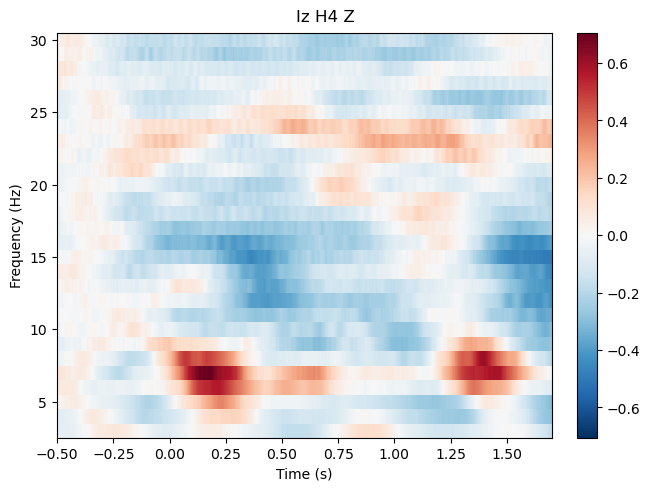

[<Figure size 640x480 with 2 Axes>]

In [11]:
sensor = 'Iz H4 Z'
tfr_slowL.plot(
    picks=sensor,
    baseline=[-0.50, -0.25],
    mode="percent",
    tmin=-0.5, tmax=1.7,
    title=sensor)

The figure above illustrates the modulation of power in response to visual stimulation. Note the typical power decrease after stimulus onset in the 10–12 Hz alpha band, and also a power decrease extending into the ~20 Hz beta band. These effects reflect a suppression of ongoing oscillatory activity induced by visual input.

The early increase at 1-5 Hz including the theta-band  reflects the spectral signature of the event-related fields (ERFs), i.e., it does not reflect true oscillatory modulation, but rather the broadband nature of evoked transients.


**Question 1:** Plot the results using an *absolute baseline*.  Why is a *relative baseline* typically used in group studies?

**Question 2:** The early 1–5 Hz power increase is attributed to the ERF rather than to a genuine oscillation. Propose a way to separate *induced* (non-phase-locked) power from this *evoked* contribution (hint: consider subtracting the ERF before computing the TFR).


To show the modulation in power for all sensors arranged topographically, write

Applying baseline correction (mode: percent)


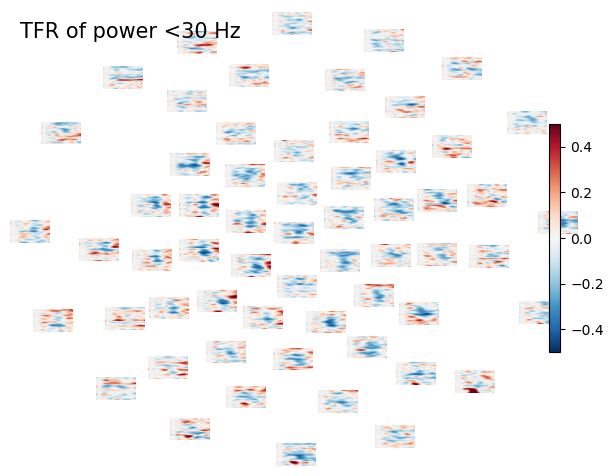

In [12]:
tfr_slowL.plot_topo(
    tmin=-0.5, tmax=1.0,
    baseline=[-0.5, -0.25],
    mode="percent",
    fig_facecolor='w',
    font_color='k',
    vmin=-0.5, vmax=0.5,
    title='TFR of power <30 Hz');

To show a topographic map of the alpha depression in the time interval from 250 to 750 ms use the plot_topomap command

Applying baseline correction (mode: percent)


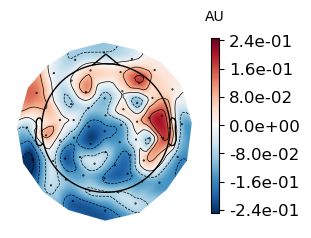

In [13]:
tfr_slowL.plot_topomap(
    tmin=0.25, tmax=0.75, 
    fmin=9, fmax=11,
    baseline=[-0.5,-0.25], 
    mode="percent",
    size=3
);

**Question 3**: Repeat the analysis with the 'attend right' trials. Are there any differences from the results of the 'attend left' trials?

**Question 4**: Change the time-window to 0.25 s and plot the results. What is the main effect in terms of time and frequency smoothing?

**Question 5**: Change the time-window to 1.00 s and plot the results. What is the main effect in terms of time and frequency smoothing?

## Comparing attend right versus attend left

Alpha activity in the cue–stimulus interval is known to be modulated by spatial attention. Numerous studies have shown that posterior alpha power decreases in the hemisphere contralateral to the attended direction, while it relatively increases in the ipsilateral hemisphere. To reveal this effect we quantify the alpha modulation in the cue–stimulus interval (0.25 to 0.75 s) using a power lateralisation index. Note that this measure is computed without baseline correction, as the two conditions are contrasted directly against each other.

In [14]:
# Power lateralisation index: (right − left) / (right + left) at each time–frequency point
tfr_slow_diff = tfr_slowL.copy()
tfr_slow_diff.data = (tfr_slowR.data - tfr_slowL.data) / (tfr_slowR.data + tfr_slowL.data)

To show the power lateralization index for all sensors write:

No baseline correction applied


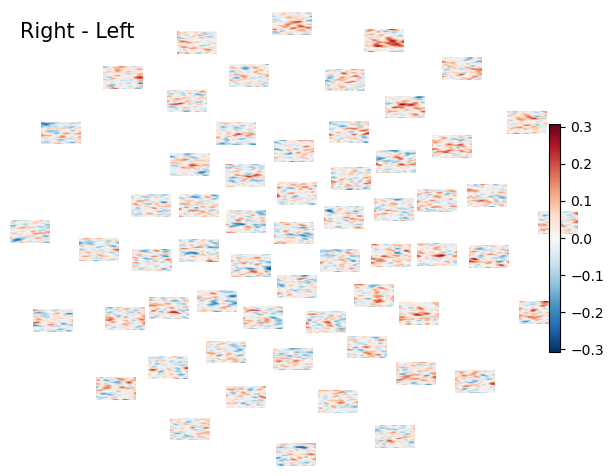

In [15]:
# The lateralisation index is already a normalised contrast, so no baseline is applied
tfr_slow_diff.plot_topo(
    tmin=-0.5, tmax=1,
    fig_facecolor='w',
    font_color='k',
    title='Right - Left');

To illustrate the lateralization index for the 10-12 Hz alpha band use the plot_topomap function:

No baseline correction applied


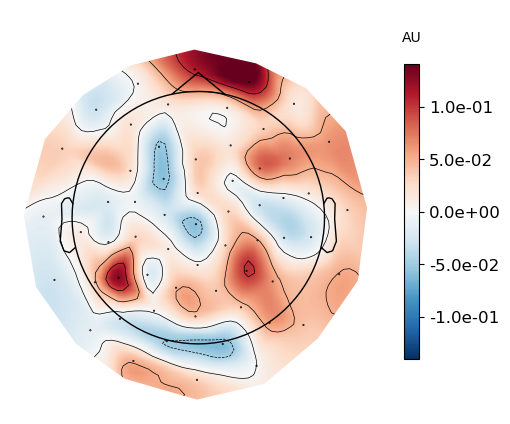

In [16]:
tfr_slow_diff.plot_topomap(tmin=0.25, tmax=0.75, fmin=10, fmax=12 , size=5,show_names=False);


**Question 6**: The lateralisation index is defined as (right − left)/(right + left). What does a positive value at a left-hemisphere sensor imply about the direction of attention, and why is this index preferred over the raw power difference (right − left)?

## Time–frequency analysis of the faster frequencies (> 30 Hz)

To resolve spectral modulations at fast frequencies more spectral smoothing is required, which is achieved with the following settings:

- `freqs` — the frequencies analysed; here 31 to 100 Hz in 2 Hz steps.
- `n_cycles` — set to `freqs/4`, giving a fixed window of ΔT ≈ 250 ms at every frequency. The relatively short window preserves good temporal resolution.
- `time_bandwidth` — set to 4.0, giving N = `time_bandwidth` − 1 = 3 tapers and a half-bandwidth of W = `time_bandwidth` / (2·ΔT) = ±8 Hz (16 Hz full width). This broad spectral smoothing is justified by the empirically broad-band nature of visual gamma activity.

For a detailed explanation of the multitaper method see [2,3]. We apply these settings to both the attend-left and attend-right conditions.

In [17]:
freqs = np.arange(31, 101, 2)
n_cycles = freqs / 4 
time_bandwidth = 4.0

tfr_fastL =  epochsL.compute_tfr(
    method = "multitaper",
    freqs=freqs, 
    n_cycles=n_cycles,
    time_bandwidth=time_bandwidth, 
    picks = 'mag',
    use_fft=True, 
    return_itc=False,
    average=True, 
    decim=1,
    n_jobs = -1)

tfr_fastR =  epochsR.compute_tfr(
    method = "multitaper",
    freqs=freqs, 
    n_cycles=n_cycles,
    time_bandwidth=time_bandwidth, 
    picks = 'mag',
    use_fft=True, 
    return_itc=False,
    average=True, 
    decim=1,
    n_jobs = -1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:   20.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:   19.6s finished


Now combine the TFRs for left and right cues:

In [18]:
tfr_fast_sum = tfr_fastL.copy()
tfr_fast_sum.data = (tfr_fastL.data + tfr_fastR.data)/2

Then plot the TFR for a posterior sensor and the left and right cue combined with respect to the gratings onset. The gratings onset occurs at t = 1.2 s and we therefore define the baseline to the 1.0 - 1.1 s interval. 

Applying baseline correction (mode: percent)


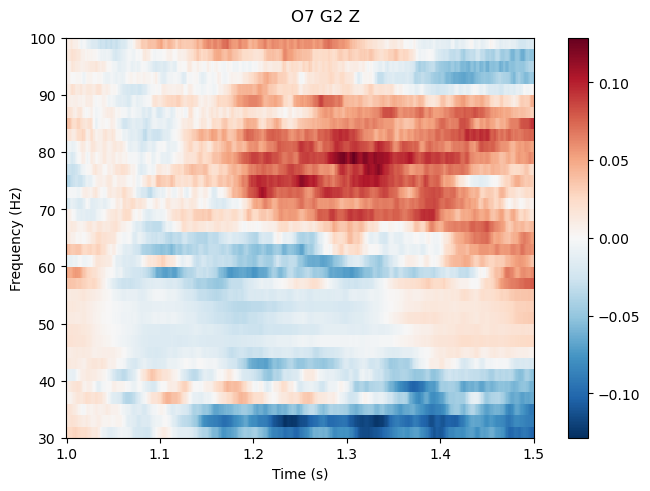

[<Figure size 640x480 with 2 Axes>]

In [19]:
%matplotlib inline
sensor = 'O7 G2 Z'
tfr_fast_sum.plot(
    picks=[sensor], 
    baseline=[1.0,1.1], 
    mode="percent", 
    tmin=1, tmax=1.5,
    title = sensor) 


Note the increase in 70-90 Hz gamma power in response to the onset (t = 1.2 s) of the gratings.

To show the TFRs for all sensors write:


Applying baseline correction (mode: percent)


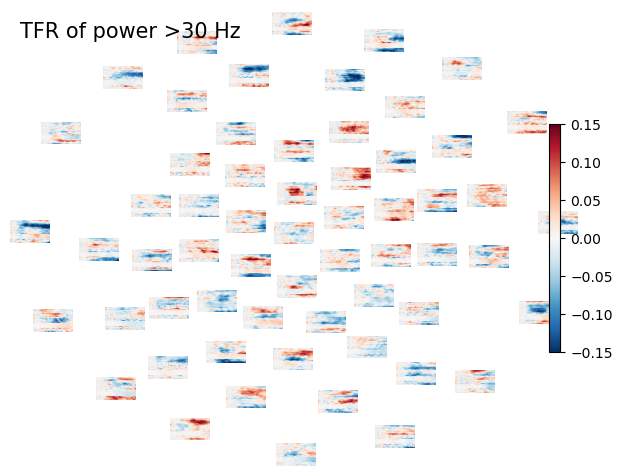

In [20]:
tfr_fast_sum.plot_topo(
    tmin=1, tmax=1.5, 
    baseline = [1,1.1], 
    mode="percent", 
    fig_facecolor='w',
    font_color='k',
    vmin=-0.15, vmax=0.15,
    title='TFR of power >30 Hz');

#### For the topographic representation for gamma activity in response to the gratings write:

Applying baseline correction (mode: percent)


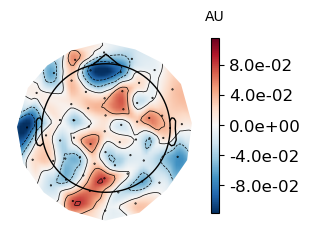

In [21]:
tfr_fast_sum.plot_topomap(
    tmin=1.2, tmax=1.5, 
    fmin=75, fmax=90, 
    baseline = [1,1.1], 
    mode="percent", 
    size=3
);



Here appreciate the posterior distribution of the gamma band activity.



**Question 7**: Change the smoothing to 20 Hz. How many tapers does this result in? What are the consequences for the time-frequency representation?

**Question 8**: Multitaper estimation reduces the variance of the power estimate at the cost of spectral resolution. Explain how averaging over K orthogonal tapers achieves this, and what happens to the estimate as K increases.

## Preregistration and publication

A preregistration should specify the time–frequency pipeline in enough detail to reproduce it exactly. The window length, taper count, frequency range, and baseline all shape the TFR, so they should be fixed in advance. We recommend committing to the following:

**Spectral estimation**
- The method (multitaper with DPSS/Slepian tapers) and the reason for choosing it.
- The frequency ranges and step sizes (here 3–30 Hz in 1 Hz steps for the low band; 31–100 Hz in 2 Hz steps for the high band).
- The window length and how it is defined (here `n_cycles = freqs/2` → ΔT = 500 ms below 30 Hz; `n_cycles = freqs/4` → ΔT = 250 ms above 30 Hz).
- The time–bandwidth product and the resulting number of tapers (here 2.0 → 1 taper for the low band; 4.0 → 3 tapers for the high band), and the corresponding spectral smoothing.
- The sensor selection (here the radial Z-axis OPM channels).

**Baseline and contrasts**
- The baseline interval and normalisation (here `mode="percent"`, −0.5 to −0.25 s for the cue-locked analysis and 1.0–1.1 s for the grating-locked gamma analysis), chosen so that the baseline does not overlap the post-event window given the ΔT-long sliding window.
- Any contrast computed without baseline correction (here the alpha lateralisation index, (right − left)/(right + left)).

**General**
- Software and versions (MNE-Python, MNE-BIDS).

**Example methods text**

> "Time–frequency representations of power were computed on single trials using the multitaper method (DPSS tapers) with a sliding time window, and then averaged across trials. For frequencies below 30 Hz a ΔT = 500 ms window was used with a time–bandwidth product of 2 (1 taper); for frequencies above 30 Hz a ΔT = 250 ms window was used with a time–bandwidth product of 4 (3 tapers). Power was expressed as the percentage change relative to a pre-event baseline (−0.5 to −0.25 s for cue-locked analyses; 1.0–1.1 s for grating-locked analyses). Spatial-attention effects were quantified as an alpha-band (10–12 Hz) lateralisation index, (right − left)/(right + left), computed without baseline correction."

## References

1. Tallon-Baudry, C., & Bertrand, O. (1999). Oscillatory gamma activity in humans and its role in object representation. *Trends in Cognitive Sciences, 3*(4), 151–162.

2. Mitra, P., & Pesaran, B. (1999). Analysis of dynamic brain imaging data. *Biophysical Journal, 76*(2), 691–708.

3. Percival, D. B., & Walden, A. T. (1993). *Spectral analysis for physical applications: Multitaper and conventional univariate techniques*. Cambridge University Press.

4. Gramfort, A., Luessi, M., Larson, E., et al. (2013). MEG and EEG data analysis with MNE-Python. *Frontiers in Neuroscience, 7*, 267. https://doi.org/10.3389/fnins.2013.00267